Epoch: 1 Total Error: 2.0
Epoch: 2 Total Error: 0.74
Epoch: 3 Total Error: 0.493
Epoch: 4 Total Error: 0.3936
Epoch: 5 Total Error: 0.3253
Epoch: 6 Total Error: 0.2707
Epoch: 7 Total Error: 0.2259
Epoch: 8 Total Error: 0.1887
Epoch: 9 Total Error: 0.158
Epoch: 10 Total Error: 0.1324
Epoch: 11 Total Error: 0.1112
Epoch: 12 Total Error: 0.0935
Epoch: 13 Total Error: 0.0788
Epoch: 14 Total Error: 0.0665
Epoch: 15 Total Error: 0.0562
Epoch: 16 Total Error: 0.0475
Epoch: 17 Total Error: 0.0403
Epoch: 18 Total Error: 0.0342
Epoch: 19 Total Error: 0.0291
Epoch: 20 Total Error: 0.0248

Final Weights:
w1 = 0.8589
w2 = -0.0195
bias = 0.0952

Testing Results:
Input: [0 0 1] Target: 0 Output: 0.0952
Input: [0 1 1] Target: 0 Output: 0.0757
Input: [1 0 1] Target: 1 Output: 0.9542
Input: [1 1 1] Target: 1 Output: 0.9347


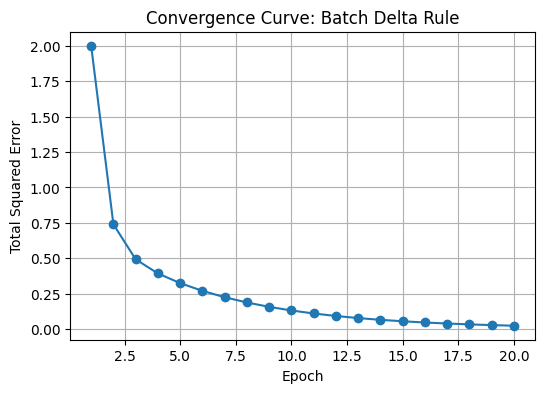

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Input data
# 3rd column = bias input
X = np.array([
    [0, 0, 1],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 1]
])

# Target output
D = np.array([0, 0, 1, 1])

# Initial weights
w = np.array([0.0, 0.0, 0.0])

# Learning rate
lr = 0.1

# Number of epochs
epochs = 20

# Store total error for convergence curve
error_list = []

# Batch Method using Delta Learning Rule
for epoch in range(epochs):
    total_error = 0
    total_weight_change = np.array([0.0, 0.0, 0.0])
    
    for i in range(len(X)):
        x = X[i]
        target = D[i]
        
        # Output calculation
        y = np.dot(w, x)
        
        # Error calculation
        error = target - y
        
        # Weight correction for this sample
        weight_change = lr * error * x
        
        # Add correction, but do not update weight yet
        total_weight_change = total_weight_change + weight_change
        
        # Store squared error
        total_error += error ** 2
    
    # Update weights once after all samples
    w = w + total_weight_change
    
    error_list.append(total_error)
    
    print("Epoch:", epoch + 1, "Total Error:", round(total_error, 4))

# Final weights
print("\nFinal Weights:")
print("w1 =", round(w[0], 4))
print("w2 =", round(w[1], 4))
print("bias =", round(w[2], 4))

# Testing
print("\nTesting Results:")
for i in range(len(X)):
    y = np.dot(w, X[i])
    print("Input:", X[i], "Target:", D[i], "Output:", round(y, 4))

# Convergence Curve
plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), error_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Total Squared Error")
plt.title("Convergence Curve: Batch Delta Rule")
plt.grid(True)
plt.show()